In [23]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import nltk
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import wordnet
nltk.download("wordnet")
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /home/suprabha/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/suprabha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/suprabha/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /home/suprabha/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [13]:
df = pd.read_csv('bbc_text_cls.csv')
df.head()

,text,labels
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


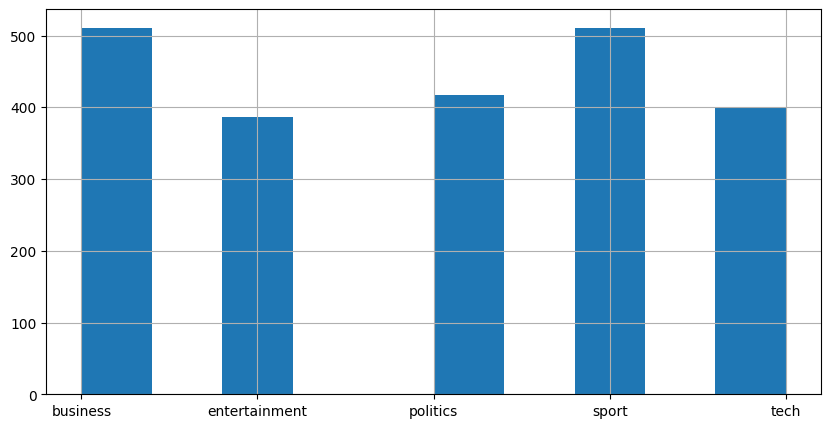

In [14]:
inputs = df['text']
labels = df['labels']
labels.hist(figsize=(10, 5));

In [15]:
inputs_train, inputs_test, Ytrain, Ytest = train_test_split(
    inputs, labels,test_size=0.3, random_state=123)
vectorizer = CountVectorizer()
Xtrain = vectorizer.fit_transform(inputs_train)
Xtest = vectorizer.transform(inputs_test)

In [16]:
model = MultinomialNB()
model.fit(Xtrain, Ytrain)
print("train score:", model.score(Xtrain, Ytrain))
print("test score:", model.score(Xtest, Ytest))

train score: 0.993577392421323
test score: 0.9745508982035929


In [17]:
model1 = RandomForestClassifier()
model1.fit(Xtrain, Ytrain)
print("train score:", model1.score(Xtrain, Ytrain))
print("test score:", model1.score(Xtest, Ytest))

train score: 1.0
test score: 0.9505988023952096


In [22]:
def get_wordnet_pos(treebank_tag):
  if treebank_tag.startswith('J'):
    return wordnet.ADJ
  elif treebank_tag.startswith('V'):
    return wordnet.VERB
  elif treebank_tag.startswith('N'):
    return wordnet.NOUN
  elif treebank_tag.startswith('R'):
    return wordnet.ADV
  else:
    return wordnet.NOUN

def lemma_tokenizer(doc):
    wnl = WordNetLemmatizer()
    tokens = word_tokenize(doc)
    words_and_tags = nltk.pos_tag(tokens)
    return [wnl.lemmatize(word, pos=get_wordnet_pos(tag)) for word, tag in words_and_tags]


In [24]:

# with lemmatization
vectorizer = CountVectorizer(tokenizer=lemma_tokenizer)
Xtrain = vectorizer.fit_transform(inputs_train)
Xtest = vectorizer.transform(inputs_test)
model1 = MultinomialNB()
model1.fit(Xtrain, Ytrain)
print("train score:", model1.score(Xtrain, Ytrain))
print("test score:", model1.score(Xtest, Ytest))
y_pred = model1.predict(Xtest)
print("\n Accuracy : ", accuracy_score(y_pred, Ytest))
print("\n Confusion matrix : ", confusion_matrix(y_pred, Ytest))
print("\n Classification report : ", classification_report(y_pred, Ytest))


train score: 0.9929351316634554
test score: 0.9670658682634731

 Accuracy :  0.9670658682634731

 Confusion matrix :  [[132   2   2   0   0]
 [  0 114   0   0   0]
 [  5   3 133   0   1]
 [  0   0   0 159   0]
 [  3   5   1   0 108]]

 Classification report :                 precision    recall  f1-score   support

     business       0.94      0.97      0.96       136
entertainment       0.92      1.00      0.96       114
     politics       0.98      0.94      0.96       142
        sport       1.00      1.00      1.00       159
         tech       0.99      0.92      0.96       117

     accuracy                           0.97       668
    macro avg       0.97      0.97      0.97       668
 weighted avg       0.97      0.97      0.97       668

